In [1]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from stepmix.stepmix import StepMix
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity


import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
df = pd.read_csv('C:\\Users\\xavis\\Xavier\\Benestar-e\\DATA\\DADES_EXCEL_TOTS_v05.csv', sep=';')
print(df.shape)
df.head()

(846, 261)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
0,1,1,18,1,1.0,1,4,2,NaN,NaN,NaN,NaN,1.0,1.0,1,0,0,0,0,21.0,0,1,0,0,0,0,0,1.0,0,0,1,0,2,1,0,1,0,0,0,0,1,0,0,0,0,0,1,3,2,6,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0,0.0,4,4,4,3,4,4,5,4,5,5,3,4,3,4,5,4,5,5,5,5,3,3,4,5,4,2,4,5,5,4,5,4,4,44,38,28,27,137,2,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,8

In [3]:
## Replace 2 with 0 in 'descans' column
df['descans'] = df['descans'].replace(2, 0)

print(df.shape)
print(df['descans'].value_counts())
df.head()

(846, 261)
descans
1.0    376
0.0    372
Name: count, dtype: int64


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
0,1,1,18,1,1.0,1,4,2,NaN,NaN,NaN,NaN,1.0,1.0,1,0,0,0,0,21.0,0,1,0,0,0,0,0,1.0,0,0,1,0,2,1,0,1,0,0,0,0,1,0,0,0,0,0,1,3,2,6,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0,0.0,4,4,4,3,4,4,5,4,5,5,3,4,3,4,5,4,5,5,5,5,3,3,4,5,4,2,4,5,5,4,5,4,4,44,38,28,27,137,2,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,8

In [4]:
## Filter the DataFrame for rows where 'GRUP' is 2 (ARS)
ARS = df[df['GRUP'].isin([2])]
print(ARS.shape)
ARS.head()

(197, 261)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
3,4,2,9,1,4.0,1,3,3,1.0,5.0,1.0,NaN,4.0,NaN,1,0,0,0,0,10.0,0,1,0,1,0,0,0,NaN,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,2,0,1,3,55.0,42.0,48.0,49.0,0.0,0.0,0.0,0.0,0,0.0,4,5,5,4,4,5,1,5,4,5,4,4,5,5,3,4,3,4,5,3,2,5,4,5,4,4,3,5,4,5,4,5,5,43,39,35,20,137,2,78.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,4.0,0.0,1.0,6.0,1.0,6.0,0.0,0.0,6.0,6.0,6.0,0.0,0.0,5.0,1.4,0.00,5.83,2.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,7.0,6.0,5.0,30.0,83

In [5]:
# Using dropna to remove rows where 'Cluster_PDI' (ARS) is NaN
ARS = ARS.dropna(subset=['Cluster_PDI'])
print(f"Final shape: {ARS.shape}")
print("Cluster distributions:")
print(ARS['Cluster_PDI'].value_counts())

print(ARS.shape)
ARS.head()

Final shape: (189, 261)
Cluster distributions:
Cluster_PDI
1.0    95
0.0    94
Name: count, dtype: int64
(189, 261)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
3,4,2,9,1,4.0,1,3,3,1.0,5.0,1.0,NaN,4.0,NaN,1,0,0,0,0,10.0,0,1,0,1,0,0,0,NaN,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,2,0,1,3,55.0,42.0,48.0,49.0,0.0,0.0,0.0,0.0,0,0.0,4,5,5,4,4,5,1,5,4,5,4,4,5,5,3,4,3,4,5,3,2,5,4,5,4,4,3,5,4,5,4,5,5,43,39,35,20,137,2,78.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,4.0,0.0,1.0,6.0,1.0,6.0,0.0,0.0,6.0,6.0,6.0,0.0,0.0,5.0,1.4,0.00,5.83,2.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,7.0,6.0,5.0,30.0,83

In [6]:
# Check for missing values in ARS
ARS.isna().sum().sum()

6137

In [7]:
# Check unique values in 'genere' (gender) column
ARS['genere'].unique()
ARS['genere'] = ARS['genere'].replace({1: 0, 2: 1}) ## 1==woman, 0==man

print(ARS['genere'].value_counts())

genere
1    115
0     74
Name: count, dtype: int64


In [8]:
# Check column names in ARS
ARS.columns.tolist()

['ID',
 'GRUP',
 'record_id',
 'genere',
 'edat_categorica',
 'nacionalitat',
 'salud',
 'situacio_economica',
 'contracte_uvic',
 'antiguitat',
 'pdi_pas',
 'centre_pas',
 'centre_pdi_estudiant',
 'centre_estudiant',
 'estudis_uvic___1',
 'estudis_uvic___2',
 'estudis_uvic___3',
 'estudis_uvic___4',
 'estudis_uvic___5',
 'graus',
 'curs___1',
 'curs___2',
 'curs___3',
 'curs___4',
 'curs___5',
 'curs___6',
 'curs___7',
 'situacio_laboral',
 'BSI1',
 'BSI2',
 'BSI3',
 'BSI4',
 'BSI5',
 'BSI6',
 'BSI7',
 'BSI8',
 'BSI9',
 'BSI10',
 'BSI11',
 'BSI12',
 'BSI13',
 'BSI14',
 'BSI15',
 'BSI16',
 'BSI17',
 'BSI18',
 'BSI_Somatització_PD',
 'BSI_Depresió_PD',
 'BSI_Ansietat_PD',
 'BSI_IGS_PD',
 'BSI_Somatització_PT',
 'BSI_Depresió_PT',
 'BSI_Ansietat_PT',
 'BSI_IGS_PT',
 'BSI_Somatització_Clínic',
 'BSI_Depresió_Clínic',
 'BSI_Ansietat_Clínic',
 'BSI_IGS_Clínic',
 'Pregunta BSI_17_Clínic_suïcidi',
 'BSI_Clínic_suïcidi',
 'sseit1',
 'sseit2',
 'sseit3',
 'sseit4',
 'sseit5',
 'sseit6',
 'sseit

In [9]:
# Rename 'FACTOR1_BENESTAR_N100' to 'Well-being Emotional Factor Five'
ARS.rename(columns={'FACTOR1_BENESTAR_N100': 'Well-being Emotional Factor Five'}, inplace=True)

In [ ]:
# Check the final column names in ARS

sociodemo = ['ID',
 'genere',   # gender
 'edat_categorica_REDUIDA', # 'age_reduced_category'
 'nacionalitat_DICO', # binary_nationality
 'salud',   # health
 'situacio_economica',  # economic_situation
 'esport',  # sport
 'hores_fisic', # hours_physical_activity
 'risc_alcohol', # alcohol_risk
 'Tranquil·litzants/pastilles per dormir', # tranquilizers/sleeping pills
 'consum-DROGUES', # drug_use
 'fumador', # smoker
 'n_cigarretes_dia',   # cigarettes_per_day
 'son', # sleep
 'descans',  # rest
 'Cluster_PDI',  # cluster_ARS 
 'Well-being Emotional Factor Five']


In [11]:
# Filter ARS to only include the sociodemographic and well-being columns
ARS = ARS[sociodemo]
print(ARS.shape)
ARS.head()

(189, 17)


,ID,genere,edat_categorica_REDUIDA,nacionalitat_DICO,salud,situacio_economica,esport,hores_fisic,risc_alcohol,Tranquil·litzants/pastilles per dormir,consum-DROGUES,fumador,n_cigarretes_dia,son,descans,Cluster_PDI,Well-being Emotional Factor Five
3,4,0,3.0,1,3,3,1.0,2.0,0.0,2.0,0.0,1.0,0.0,2.0,1.0,1.0,83.783082
4,5,0,3.0,1,4,2,1.0,3.0,0.0,2.0,0.0,3.0,2.0,2.0,0.0,0.0,55.439787
5,6,0,2.0,1,4,4,1.0,3.0,0.0,2.0,0.0,3.0,2.0,2.0,1.0,1.0,85.495721
6,7,0,3.0,1,4,3,2.0,0.0,0.0,2.0,0.0,2.0,2.0,2.0,1.0,1.0,93.603427
9,10,1,2.0,2,5,2,1.0,5.0,0.0,1.0,0.0,1.0,0.0,2.0,1.0,0.0,33.764174


In [12]:
# print the number of missing values in each column of ARS
ARS = ARS.dropna()
print(f"New shape: ", ARS.shape)
print(ARS.isna().sum())


New shape:  (182, 17)
ID                                        0
genere                                    0
edat_categorica_REDUIDA                   0
nacionalitat_DICO                         0
salud                                     0
situacio_economica                        0
esport                                    0
hores_fisic                               0
risc_alcohol                              0
Tranquil·litzants/pastilles per dormir    0
consum-DROGUES                            0
fumador                                   0
n_cigarretes_dia                          0
son                                       0
descans                                   0
Cluster_PDI                               0
Well-being Emotional Factor Five          0
dtype: int64


In [13]:
# Check the new distribution of clusters in ARS
ARS['Cluster_PDI'].value_counts()

Cluster_PDI
1.0    91
0.0    91
Name: count, dtype: int64

In [14]:
# Check the number of unique categories in each column of ARS
for col in ARS.columns:
    print(f"{col}: {ARS[col].nunique()} categories")

ID: 182 categories
genere: 2 categories
edat_categorica_REDUIDA: 3 categories
nacionalitat_DICO: 2 categories
salud: 4 categories
situacio_economica: 4 categories
esport: 2 categories
hores_fisic: 6 categories
risc_alcohol: 2 categories
Tranquil·litzants/pastilles per dormir: 2 categories
consum-DROGUES: 2 categories
fumador: 3 categories
n_cigarretes_dia: 5 categories
son: 2 categories
descans: 2 categories
Cluster_PDI: 2 categories
Well-being Emotional Factor Five: 180 categories


In [15]:
# Nomality tests for 'Well-being Emotional Factor Five' in ARS

from scipy.stats import shapiro, normaltest, kstest
import pandas as pd

print("Normality tests for the Well-being Emotional Factor Five:")
x = ARS["Well-being Emotional Factor Five"].dropna()

# # Shapiro-Wilk
# stat, p = shapiro(x)
# print(f"Shapiro-Wilk → estadístico={stat:.3f}, p={p:.3f}")

# # D’Agostino & Pearson
# stat2, p2 = normaltest(x)
# print(f"D’Agostino-Pearson → estadístico={stat2:.3f}, p={p2:.3f}")

# Kolmogorov-Smirnov
from scipy.stats import norm
stat3, p3 = kstest(x, 'norm', args=(x.mean(), x.std()))
print(f"Kolmogorov-Smirnov → estadístico={stat3:.3f}, p={p3:.3f}")


Normality tests for the Well-being Emotional Factor Five:
Kolmogorov-Smirnov → estadístico=0.091, p=0.089


UPDATED CODES:
genere                                   → B (Genuine dichotomous)
edat_categorica_REDUIDA                  → D (Ordinal/ranks)
nacionalitat_DICO                        → B (Genuine dichotomous)
salud                                    → D (Ordinal/ranks)
situacio_economica                       → D (Ordinal/ranks)
esport                                   → B (Genuine dichotomous)
hores_fisic                              → D (Ordinal/ranks)
risc_alcohol                             → C (Artificial dichotomous)
Tranquil·litzants/pastilles per dormir   → B (Genuine dichotomous)
consum-DROGUES                           → B (Genuine dichotomous)
fumador                                  → A (Nominal 3+ cat)
n_cigarretes_dia                         → D (Ordinal/ranks)
son                                      → B (Genuine dichotomous)
descans                                  → B (Genuine dichotomous)
Well-being Emotional Factor Five         → F (Non-normal continuous)
Cluster_PD

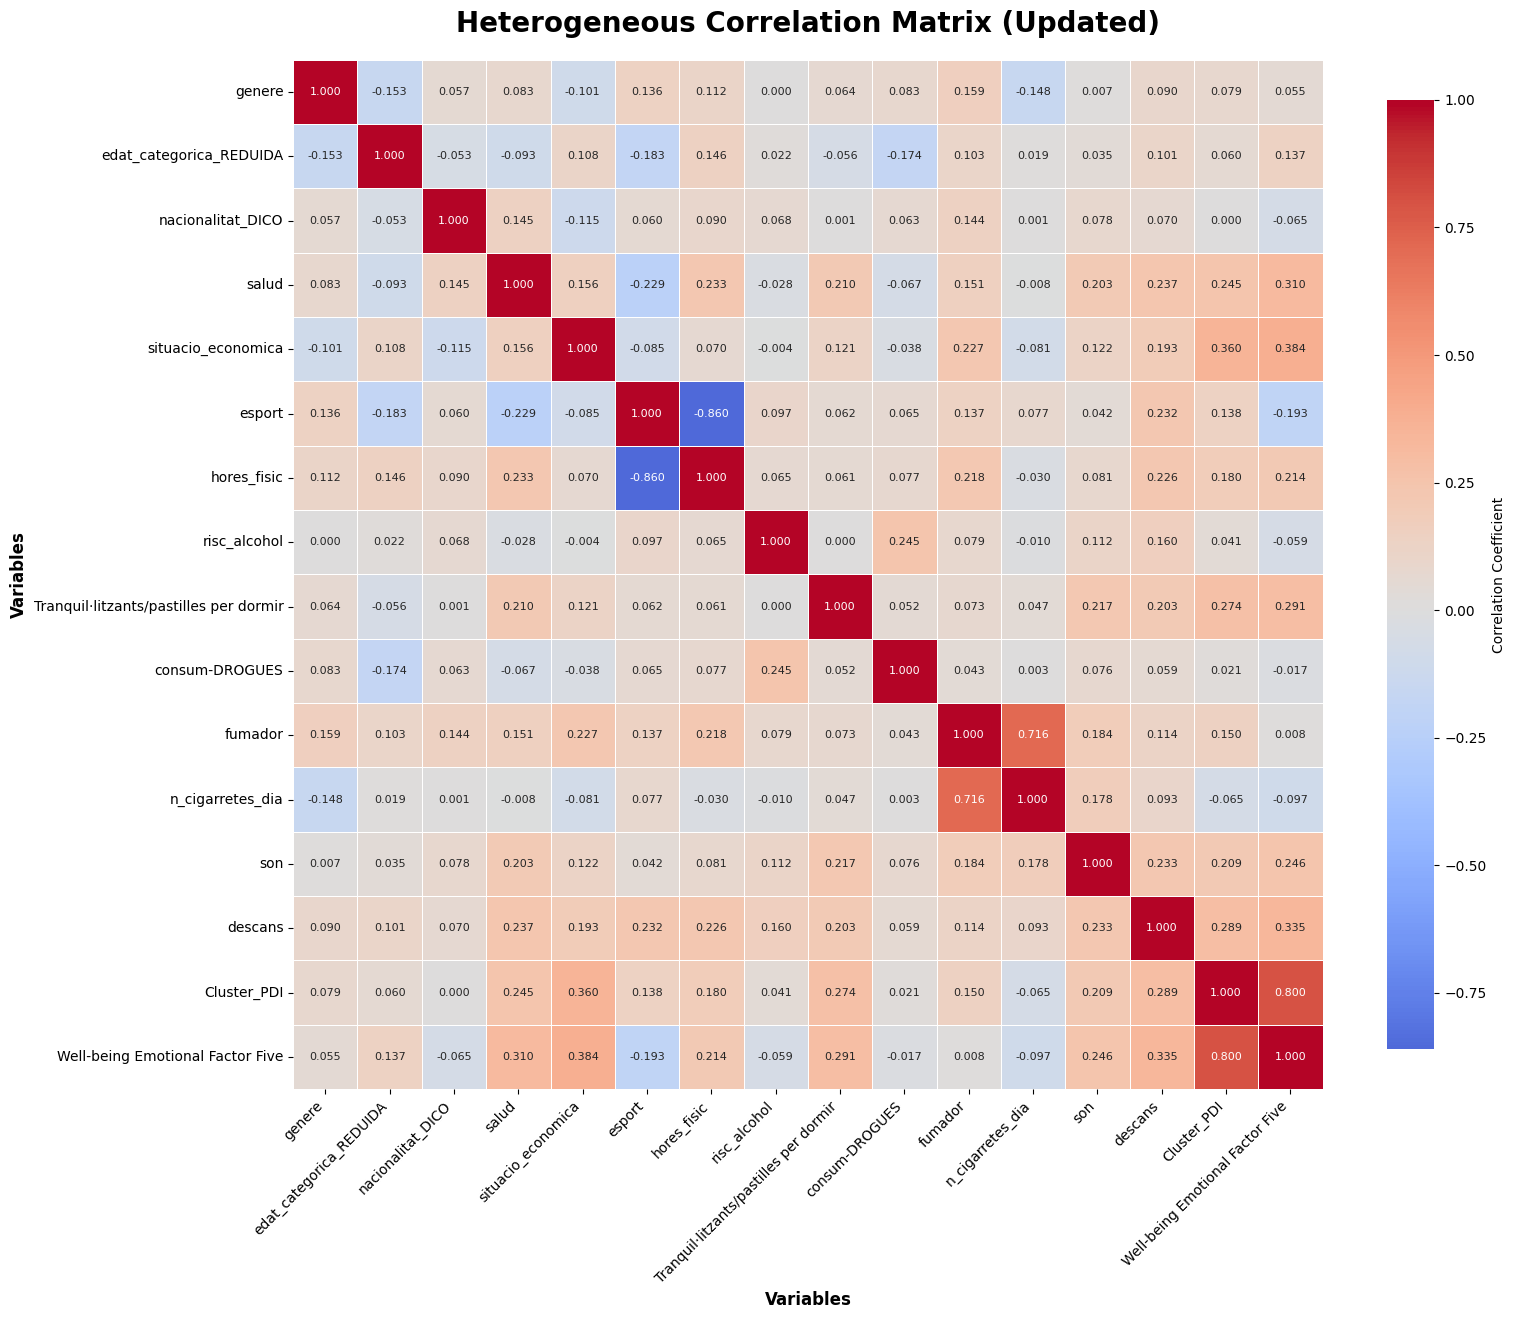


UPDATED CORRELATION MATRIX:
                                        genere  edat_categorica_REDUIDA  \
genere                                   1.000                   -0.153   
edat_categorica_REDUIDA                 -0.153                    1.000   
nacionalitat_DICO                        0.057                   -0.053   
salud                                    0.083                   -0.093   
situacio_economica                      -0.101                    0.108   
esport                                   0.136                   -0.183   
hores_fisic                              0.112                    0.146   
risc_alcohol                             0.000                    0.022   
Tranquil·litzants/pastilles per dormir   0.064                   -0.056   
consum-DROGUES                           0.083                   -0.174   
fumador                                  0.159                    0.103   
n_cigarretes_dia                        -0.148                    0.019

In [16]:
## --- IMPORTS FOR CORRELATION ANALYSIS

import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr, pointbiserialr, chi2_contingency
from scipy.stats.contingency import association
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from scipy.stats import kendalltau

# --- Phi of Pearson Function (for genuine dichotomous variables)
def phi_pearson(x, y):
    """Pearson Phi coefficient for two genuine dichotomous variables"""
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    return np.sqrt(chi2 / n)

# --- Tetrachoric Function (approximation for artificial dichotomous variables)
def tetrachorica_aprox(x, y):
    """Tetrachoric correlation approximation using transformation"""
    try:
        # Convert to 0/1 if not already
        x_bin = (x == x.max()).astype(int)
        y_bin = (y == y.max()).astype(int)
        # Use phi as approximation
        return phi_pearson(x_bin, y_bin)
    except:
        return np.nan

# --- Biserial Function (approximation)
def biserial_aprox(cont, dico):
    """Biserial correlation approximation"""
    try:
        # Use point-biserial as improved approximation
        return pointbiserialr(dico, cont)[0]
    except:
        return np.nan

# --- Contingency Coefficient Function
def coeficiente_contingencia(x, y):
    """Contingency coefficient for nominal variables"""
    try:
        tabla = pd.crosstab(x, y)
        chi2 = chi2_contingency(tabla)[0]
        n = tabla.sum().sum()
        return np.sqrt(chi2 / (chi2 + n))
    except:
        return np.nan

def kruskal_wallis_effect_size(nominal, continua):
    """
    Calculates Kruskal-Wallis test and its effect size (epsilon-squared)
    for nominal vs continuous when normality is not met
    """
    try:
        # Create groups based on the nominal variable
        grupos = [continua[nominal == categoria].dropna() for categoria in nominal.unique()]
        
        # Filter empty groups
        grupos = [grupo for grupo in grupos if len(grupo) > 0]
        
        if len(grupos) < 2:
            return np.nan
        
        # Kruskal-Wallis test
        h_stat, p_valor = kruskal(*grupos)
        
        # Calculate epsilon-squared (effect size for Kruskal-Wallis)
        n_total = sum(len(grupo) for grupo in grupos)
        epsilon_squared = (h_stat - len(grupos) + 1) / (n_total - len(grupos))
        
        # Ensure it is between 0 and 1
        epsilon_squared = max(0, min(1, epsilon_squared))
        
        return epsilon_squared
        
    except Exception as e:
        return np.nan

# --- Main function UPDATED according to the variable type table
def matriz_correlacion_mixta(df, codigos):
    """
    Heterogeneous correlation matrix based on variable types
    codigos = {'var1':'A','var2':'B',...}
    A = Nominal 3+ categories
    B = Genuine dichotomous
    C = Artificial dichotomous
    D = Ordinal/ranks
    E = Normal continuous
    F = Non-normal continuous
    """

    vars_all = [v for v in df.columns if v in codigos]
    n = len(vars_all)
    
    corr_matrix = pd.DataFrame(np.zeros((n,n)), index=vars_all, columns=vars_all)
    metodo_matrix = pd.DataFrame('', index=vars_all, columns=vars_all)

    for i, var1 in enumerate(vars_all):
        for j, var2 in enumerate(vars_all):

            if i == j:
                corr_matrix.loc[var1, var2] = 1.0
                metodo_matrix.loc[var1, var2] = "Diagonal"
                continue

            x, y = df[var1], df[var2]
            t1, t2 = codigos[var1], codigos[var2]

            try:
                # --- COMBINED KEYS (sort alphabetically) ---
                combo = ''.join(sorted([t1, t2]))

                # --- Application according to variable type table ---
                if combo == "CC":  # Artificial dichotomous ↔ Artificial dichotomous
                    r = tetrachorica_aprox(x, y)
                    metodo = "Tetrachoric"

                elif combo == "CE":  # Artificial dichotomous ↔ Normal continuous
                    r = biserial_aprox(y if t2 == 'E' else x, x if t2 == 'E' else y)
                    metodo = "Biserial"

                elif combo == "BB":  # Genuine dichotomous ↔ Genuine dichotomous
                    r = phi_pearson(x, y)
                    metodo = "Pearson's Phi"

                elif combo == "BE":  # Genuine dichotomous ↔ Normal continuous
                    r = pointbiserialr(x if t1 == 'B' else y, y if t1 == 'B' else x)[0]
                    metodo = "Point-biserial"

                elif combo == "EE":  # Normal continuous ↔ Normal continuous
                    r, _ = pearsonr(x, y)
                    metodo = "Pearson"

                elif combo == "EF":  # Normal continuous ↔ Non-normal continuous
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "FF":  # Non-normal continuous ↔ Non-normal continuous
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "DD":  # Ordinal ↔ Ordinal
                    r, _ = kendalltau(x, y)
                    metodo = "Kendall-Tau"

                elif combo == "BD":  # Genuine dichotomous ↔ Ordinal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "CD":  # Artificial dichotomous ↔ Ordinal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "AD":  # Nominal ↔ Ordinal
                    r = coeficiente_contingencia(x, y)
                    metodo = "Contingency coefficient"

                elif combo == "AA":  # Nominal ↔ Nominal
                    r = association(pd.crosstab(x, y), method="cramer")
                    metodo = "Cramer's V"

                elif combo == "AF":  # Nominal ↔ Non-normal continuous
                    r = kruskal_wallis_effect_size(x if t1 == 'A' else y, y if t1 == 'A' else x)
                    metodo = "Kruskal-Wallis"

                elif combo == "AE":  # Nominal ↔ Normal continuous
                    r = kruskal_wallis_effect_size(x if t1 == 'A' else y, y if t1 == 'A' else x)
                    metodo = "Kruskal-Wallis"

                elif combo == "BC":  # Genuine dichotomous ↔ Artificial dichotomous
                    r = phi_pearson(x, y)
                    metodo = "Pearson's Phi"

                elif combo == "AB":  # Nominal ↔ Genuine dichotomous
                    r = association(pd.crosstab(x, y), method="cramer")
                    metodo = "Chi-squared/Cramer's V"

                elif combo == "AC":  # Nominal ↔ Artificial dichotomous
                    r = association(pd.crosstab(x, y), method="cramer")
                    metodo = "Cramer's V"

                elif combo == "BF":  # Genuine dichotomous ↔ Non-normal continuous
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "CF":  # Artificial dichotomous ↔ Non-normal continuous
                    r = biserial_aprox(y if t2 == 'F' else x, x if t2 == 'F' else y)
                    metodo = "Biserial/Mann-Whitney"

                elif combo == "DE":  # Ordinal ↔ Normal continuous
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "DF":  # Ordinal ↔ Non-normal continuous
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                else:
                    r = np.nan
                    metodo = "Not defined"

            except:
                r = np.nan
                metodo = "Error"

            corr_matrix.loc[var1, var2] = r
            metodo_matrix.loc[var1, var2] = metodo

    # VISUALIZACIÓN
    plt.figure(figsize=(16, 14))
    
    sns.heatmap(
        corr_matrix.astype(float), 
        cmap='coolwarm', 
        center=0,
        annot=True, 
        fmt='.3f',
        annot_kws={'size': 8},
        square=True, 
        linewidths=0.5,
        cbar_kws={"shrink": .8, "label": "Correlation Coefficient"}
    )
    
    plt.title("Heterogeneous Correlation Matrix (Updated)", fontsize=20, fontweight='bold', pad=20)
    plt.xlabel("Variables", fontsize=12, fontweight='bold')
    plt.ylabel("Variables", fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

    return corr_matrix, metodo_matrix

codigos_actualizados = {
    "genere": "B",                           # Genuine dichotomous
    "edat_categorica_REDUIDA": "D",          # Ordinal 3 cat
    "nacionalitat_DICO": "B",                # Genuine dichotomous
    "salud": "D",                           # Ordinal 5 cat
    "situacio_economica": "D",              # Ordinal 4 cat
    "esport": "B",                          # Genuine dichotomous
    "hores_fisic": "D",                     # Ordinal 6 cat
    "risc_alcohol": "C",                    # Artificial dichotomous
    "Tranquil·litzants/pastilles per dormir": "B",  # Genuine dicotomous
    "consum-DROGUES": "B",                  # Genuine dichotomous
    "fumador": "A",                         # Nominal 3 cat
    "n_cigarretes_dia": "D",               # Ordinal 4 cat
    "son": "B",                            # Genuine dichotomous
    "descans": "B",                        # Genuine dichotomous
    "Well-being Emotional Factor Five": "F",          # Non-normal continuous
    "Cluster_PDI": "C"                     # Artificial dichotomous
}

print("UPDATED CODES:")
for var, codigo in codigos_actualizados.items():
    tipo_desc = {
        'A': 'Nominal 3+ cat',
        'B': 'Genuine dichotomous', 
        'C': 'Artificial dichotomous',
        'D': 'Ordinal/ranks',
        'E': 'Normal continuous',
        'F': 'Non-normal continuous'
    }
    print(f"{var:<40} → {codigo} ({tipo_desc[codigo]})")

# --- EJECUTAR ANÁLISIS ACTUALIZADO ---
print("\n" + "="*80)
print("RUNNING UPDATED HETEROGENEOUS CORRELATION MATRIX")
print("="*80)

# Filter only variables present in the dictionary
variables_analizar = [var for var in ARS.columns if var in codigos_actualizados and var != 'ID']
df_filtrado = ARS[variables_analizar]

corr_matrix_actualizada, metodos_actualizados = matriz_correlacion_mixta(df_filtrado, codigos_actualizados)

print("\nUPDATED CORRELATION MATRIX:")
print(corr_matrix_actualizada.round(3))

print("\nUPDATED METHODS USED:")
print(metodos_actualizados)

In [18]:
# ================ DESCRIPTIVE ANALYSIS BY CLUSTERS ================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import association
import warnings
warnings.filterwarnings('ignore')

# Sociodemographic variables 
vars_sociodemo = [col for col in ARS.columns if col not in ['ID']]

# 1. General distributions of clusters
print(f"\n1. GENERAL DISTRIBUTIONS OF CLUSTERS:")
print(ARS['Cluster_PDI'].value_counts().sort_index())
print(f"Porcentajes:")
print(ARS['Cluster_PDI'].value_counts(normalize=True).sort_index().round(3) * 100)




1. GENERAL DISTRIBUTIONS OF CLUSTERS:
Cluster_PDI
0.0    91
1.0    91
Name: count, dtype: int64
Porcentajes:
Cluster_PDI
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


In [37]:
# ================ ESTADISTIC ASSOCIATION TESTS================

from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import association
import pandas as pd

def calcular_v_cramer(chi2, n, min_dim):
    """Calcula la V de Cramér"""
    return np.sqrt(chi2 / (n * (min_dim - 1)))

resultados_tests = []

print("\n" + "=" * 80)
print(" STATISTICAL ASSOCIATION TESTS")
print("=" * 80)

for variable in vars_sociodemo:
    if variable != 'Cluster_PDI':
        print(f"\nAnalizando: {variable}")

        # contingencia table (without margins)
        tabla = pd.crosstab(ARS[variable], ARS['Cluster_PDI'])

        # Test Chi-squared
        try:
            chi2, p_valor, dof, expected = chi2_contingency(tabla)
            n = tabla.sum().sum()
            min_dim = min(tabla.shape)
            v_cramer = calcular_v_cramer(chi2, n, min_dim)

            # Determine significance
            significativo = p_valor < 0.05

            # V de Cramér interpretation
            if v_cramer < 0.1:
                fuerza = "Very weak"
            elif v_cramer < 0.3:
                fuerza = "Weak"
            elif v_cramer < 0.5:
                fuerza = "Moderate"
            else:
                fuerza = "Strong"

            print(f"  Chi² = {chi2:.4f}, p-valor = {p_valor:.6f}")
            print(f"  V de Cramér = {v_cramer:.4f} ({fuerza})")
            print(f"  Significativo: {'SÍ' if significativo else 'NO'}")

            resultados_tests.append({
                'Variable': variable,
                'Chi2': chi2,
                'p_valor': p_valor,
                'V_Cramer': v_cramer,
                'Significativo': significativo,
                'Fuerza_Asociacion': fuerza,
                'Categorias': tabla.shape[0]
            })

        except Exception as e:
            print(f"  Error en el test: {e}")
            resultados_tests.append({
                'Variable': variable,
                'Chi2': np.nan,
                'p_valor': np.nan,
                'V_Cramer': np.nan,
                'Significativo': False,
                'Fuerza_Asociacion': 'Error',
                'Categorias': tabla.shape[0]
            })

# Create DataFrame with results 
df_tests = pd.DataFrame(resultados_tests)
df_tests = df_tests.sort_values('V_Cramer', ascending=False)

print("\n" + "=" * 80)
print(" RESUMEN DE TESTS DE ASOCIACIÓN")
print("=" * 80)
print(df_tests.round(4))

# Associate variables with the clusters 
print(f"\n" + "=" * 60)
print(" TOP 10 VARIABLES MÁS ASOCIADAS CON CLUSTERS")
print("=" * 60)
top_variables = df_tests.head(10)[['Variable', 'V_Cramer', 'p_valor', 'Significativo', 'Fuerza_Asociacion']]
print(top_variables)


 STATISTICAL ASSOCIATION TESTS

Analizando: genere
  Chi² = 1.1260, p-valor = 0.288628
  V de Cramér = 0.0787 (Very weak)
  Significativo: NO

Analizando: edat_categorica_REDUIDA
  Chi² = 4.1361, p-valor = 0.126432
  V de Cramér = 0.1508 (Weak)
  Significativo: NO

Analizando: nacionalitat_DICO
  Chi² = 0.0000, p-valor = 1.000000
  V de Cramér = 0.0000 (Very weak)
  Significativo: NO

Analizando: salud
  Chi² = 13.2014, p-valor = 0.004221
  V de Cramér = 0.2693 (Weak)
  Significativo: SÍ

Analizando: situacio_economica
  Chi² = 25.9191, p-valor = 0.000010
  V de Cramér = 0.3774 (Moderate)
  Significativo: SÍ

Analizando: esport
  Chi² = 3.4462, p-valor = 0.063399
  V de Cramér = 0.1376 (Weak)
  Significativo: NO

Analizando: hores_fisic
  Chi² = 9.1871, p-valor = 0.101830
  V de Cramér = 0.2247 (Weak)
  Significativo: NO

Analizando: risc_alcohol
  Chi² = 0.3116, p-valor = 0.576673
  V de Cramér = 0.0414 (Very weak)
  Significativo: NO

Analizando: Tranquil·litzants/pastilles per dorm

In [21]:
import pandas as pd
import scipy.stats as stats
import numpy as np

print("Cluster comparison by variable using Chi-square tests and effect size estimation with Cramer's V.\nTo provide an alternative approach for identifying significantly different variables.")

def chi2_assoc(df, var, cluster_col='Cluster_PDI'):
    tabla = pd.crosstab(df[var], df[cluster_col])
    chi2, p, dof, _ = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    phi2 = chi2/n
    r, k = tabla.shape
    cramers_v = np.sqrt(phi2 / min(k-1, r-1))
    return {'Variable': var, 'p_value': p, 'CramerV': cramers_v}

columnas_excluir = ['Cluster_PDI', 'ID']
vars_sociodemo_filtradas = [var for var in vars_sociodemo if var not in columnas_excluir]

print(f"Variables to be analyzed: {len(vars_sociodemo_filtradas)}")

resultados = []
for var in vars_sociodemo_filtradas:
    if var in ARS.columns:  
        results = chi2_assoc(ARS, var)
        if results['p_value'] < 0.05:
            resultados.append(results)
    else:
        print(f"Warning: {var} does not exist in the DataFrame")

pd.DataFrame(resultados).sort_values('p_value')

Cluster comparison by variable using Chi-square tests and effect size estimation with Cramer's V.
To provide an alternative approach for identifying significantly different variables.
Variables to be analyzed: 15


,Variable,p_value,CramerV
1,situacio_economica,0.000010,0.377376
4,descans,0.000096,0.289157
2,Tranquil·litzants/pastilles per dormir,0.000216,0.274241
0,salud,0.004221,0.269323
3,son,0.004757,0.209256


In [25]:
import statsmodels.api as sm
import numpy as np

# Verify distribution of 'descans'
print("Distribution of 'descans':")
print(ARS['descans'].value_counts().sort_index())

X = ARS[['salud', 'situacio_economica', 'Tranquil·litzants/pastilles per dormir', 
                'descans', 'son', 'consum-DROGUES', 'esport', 'hores_fisic', 'genere']]
X = pd.get_dummies(X, drop_first=True)
y = (ARS['Cluster_PDI'] == 0).astype(int)
X = sm.add_constant(X)

model = sm.Logit(y, X).fit()

# Extraer coeficiente de descans
print("\n" + "="*60)
print("VERIFICATION OF THE COEFFICIENT OF DESCANS")
print("="*60)

if 'descans' in model.params.index:
    coef_descans = model.params['descans']
    p_descans = model.pvalues['descans']
    or_descans = np.exp(coef_descans)
    
    print(f"Coeficiente: {coef_descans:.4f}")
    print(f"P-valor: {p_descans:.4f}")
    print(f"Odds Ratio: {or_descans:.4f}")
    print(f"Significativo: {'SÍ' if p_descans < 0.05 else 'NO'}")
    
    if coef_descans < 0:

        print(f"INTERPRETATION: Good sleep (1) reduces the probability of Cluster 1")
        print(f"   Reduction: {(1-or_descans)*100:.1f}%")
    else:
        print(f"⚠️ INTERPRETATION: Good sleep (1) INCREASES the probability of Cluster 1")
        print(f"   Increase: {(or_descans-1)*100:.1f}%")
else:
    print("❌ Variable 'descans' not found in the model")

print("\n" + "="*60)
print("COMPLETE SUMMARY OF THE MODEL")
print("="*60)
print(model.summary())

Distribution of 'descans':
descans
0.0     77
1.0    105
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.532420
         Iterations 6

VERIFICATION OF THE COEFFICIENT OF DESCANS
Coeficiente: -0.9419
P-valor: 0.0135
Odds Ratio: 0.3899
Significativo: SÍ
INTERPRETATION: Good sleep (1) reduces the probability of Cluster 1
   Reduction: 61.0%

COMPLETE SUMMARY OF THE MODEL
                           Logit Regression Results                           
Dep. Variable:            Cluster_PDI   No. Observations:                  182
Model:                          Logit   Df Residuals:                      172
Method:                           MLE   Df Model:                            9
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                  0.2319
Time:                        10:40:55   Log-Likelihood:                -96.901
converged:                       True   LL-Null:                       -126.15
Covariance Type:         

In [38]:
## Additional metrics for model evaluation

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from scipy.stats import chi2

# ── Pseudo-R² de Nagelkerke ───────────────────────────────────────────────────
n = model.nobs
ll_full = model.llf
ll_null = model.llnull
cox_snell  = 1 - np.exp((2/n) * (ll_null - ll_full))
nagelkerke = cox_snell / (1 - np.exp((2/n) * ll_null))

# ── Hosmer-Lemeshow ───────────────────────────────────────────────────────────
def hosmer_lemeshow(y_true, y_pred, g=10):
    df_hl = pd.DataFrame({'y': y_true.values, 'p': y_pred})
    df_hl['grupo'] = pd.qcut(df_hl['p'], g, duplicates='drop')
    grp = df_hl.groupby('grupo', observed=True)
    obs1 = grp['y'].sum();  obs0 = grp['y'].count() - obs1
    exp1 = grp['p'].sum();  exp0 = grp['p'].count() - exp1
    hl = ((obs1-exp1)**2/exp1 + (obs0-exp0)**2/exp0).sum()
    df_gl = grp.ngroups - 2
    return hl, df_gl, 1 - chi2.cdf(hl, df_gl)

y_pred = model.predict()
hl_stat, hl_df, hl_p = hosmer_lemeshow(y, y_pred)
auc = roc_auc_score(y, y_pred)

# ── Tabla completa ────────────────────────────────────────────────────────────
params = model.params
se     = model.bse
z      = model.tvalues
pvals  = model.pvalues
ci     = model.conf_int()
OR     = np.exp(params)
OR_lo  = np.exp(ci[0])
OR_hi  = np.exp(ci[1])

def sig(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

print("=" * 95)
print("  TABLE 4 — Binary Logistic Regression: PDI")
print(f"  Dependent Variable: Cluster_PDI = 0 (worst well-being)  |  N = {int(n)}")
print("=" * 95)
print(f"{'Variable':<42} {'β':>7} {'SE':>7} {'z':>7} {'p':>7}     {'OR':>7} {'95% CI':>20}")
print("-" * 95)

etiquetas = {
    'const':                                    'Constante',
    'salud':                                    'Salud autopercibida',
    'situacio_economica':                       'Situación económica',
    'Tranquil·litzants/pastilles per dormir':   'Tranquilizantes/hipnóticos',
    'son':                                      'Calidad del sueño',
    'descans':                                  'Descanso',
    'consum-DROGUES':                           'Consumo de drogas',
    'esport':                                   'Práctica deportiva',
    'hores_fisic':                              'Horas de actividad física',
    'genere':                                   'Género',
}

for v in params.index:
    label   = etiquetas.get(v, v)
    ci_str  = f"[{OR_lo[v]:.3f}, {OR_hi[v]:.3f}]"
    p_str   = f"{pvals[v]:.3f}{sig(pvals[v])}"
    print(f"{label:<42} {params[v]:>7.3f} {se[v]:>7.3f} {z[v]:>7.3f} {p_str:>10} {OR[v]:>7.3f} {ci_str:>20}")

print("-" * 95)
print(f"  Pseudo R² de McFadden    = {model.prsquared:.3f}")
print(f"  Pseudo R² de Cox-Snell   = {cox_snell:.3f}")
print(f"  Pseudo R² de Nagelkerke  = {nagelkerke:.3f}")
print(f"  AIC                      = {model.aic:.2f}")
print(f"  BIC                      = {model.bic:.2f}")
print(f"  Log-verosimilitud        = {model.llf:.3f}")
print(f"  p-valor LRT              = {model.llr_pvalue:.2e}")
print(f"  AUC-ROC                  = {auc:.3f}")
print(f"  Hosmer-Lemeshow χ²({hl_df})  = {hl_stat:.3f}, p = {hl_p:.3f}")
print()
print("  Categorías de referencia:")
print("    Gender: 0 = woman  |  Tranquilizantes: 0 = no consume")
print("    Descanso: 1 = buen descanso  |  Sueño: 1 = buena calidad")
print()
print("  * p < .05   ** p < .01   *** p < .001")
print("=" * 95)


  TABLE 4 — Binary Logistic Regression: PDI
  Dependent Variable: Cluster_PDI = 0 (worst well-being)  |  N = 182
Variable                                         β      SE       z       p          OR               95% CI
-----------------------------------------------------------------------------------------------
Constante                                   10.150   2.165   4.687   0.000*** 25600.576 [367.276, 1784461.984]
Salud autopercibida                         -0.354   0.298  -1.189      0.234   0.702       [0.392, 1.258]
Situación económica                         -1.180   0.288  -4.096   0.000***   0.307       [0.175, 0.540]
Tranquilizantes/hipnóticos                  -1.416   0.544  -2.601    0.009**   0.243       [0.084, 0.705]
Descanso                                    -0.942   0.381  -2.472     0.013*   0.390       [0.185, 0.823]
Calidad del sueño                           -0.519   0.414  -1.253      0.210   0.595       [0.264, 1.340]
Consumo de drogas                    

In [28]:

# Extracting information from the model
coeficientes = model.params
p_valores = model.pvalues
odds_ratios = np.exp(coeficientes)

# Function to calculate percentage change
def calcular_cambio_porcentual(or_value):
    if or_value > 1:
        cambio = (or_value - 1) * 100
        direccion = "INCREASES"
    elif or_value < 1:
        cambio = (1 - or_value) * 100
        direccion = "REDUCE"
    else:
        cambio = 0
        direccion = "NO CHANGE"
    return cambio, direccion

# Create DataFrame with results
resultados = []

for variable in coeficientes.index:
    if variable == 'const':
        continue
    
    coef = coeficientes[variable]
    p_val = p_valores[variable]
    or_val = odds_ratios[variable]
    cambio, direccion = calcular_cambio_porcentual(or_val)
    
    resultados.append({
        'Variable': variable,
        'Coeficiente': coef,
        'P-valor': p_val,
        'Odds_Ratio': or_val,
        'Cambio_%': cambio,
        'Direccion': direccion,
        'Significativo': 'Si' if p_val < 0.05 else 'No'
    })

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('P-valor')

print("ALL THE VARIABLES OF THE MODEL:")
print("="*80)
print(df_resultados.to_string(index=False))

df_significativas = df_resultados[df_resultados['Significativo'] == 'Si']

print("\n\nONLY SIGNIFICANT VARIABLES (p < 0.05):")
print("="*80)
print(df_significativas.to_string(index=False))

print("\n\nINDIVIDUAL INTERPRETATION:")
print("="*80)

for _, row in df_significativas.iterrows():
    print(f"\n{row['Variable']}")
    print(f"  Coeficiente: {row['Coeficiente']:.4f}")
    print(f"  P-valor: {row['P-valor']:.4f}")
    print(f"  Odds Ratio: {row['Odds_Ratio']:.4f}")
    print(f"  Direccion: {row['Direccion']} {row['Cambio_%']:.1f}%")

ALL THE VARIABLES OF THE MODEL:
                              Variable  Coeficiente  P-valor  Odds_Ratio  Cambio_% Direccion Significativo
                    situacio_economica    -1.180305 0.000042    0.307185 69.281496    REDUCE            Si
Tranquil·litzants/pastilles per dormir    -1.415722 0.009283    0.242750 75.724960    REDUCE            Si
                               descans    -0.941862 0.013450    0.389901 61.009874    REDUCE            Si
                                genere    -0.877935 0.021647    0.415640 58.435964    REDUCE            Si
                                   son    -0.519269 0.210205    0.594955 40.504455    REDUCE            No
                                 salud    -0.354112 0.234372    0.701797 29.820348    REDUCE            No
                           hores_fisic    -0.230226 0.248716    0.794354 20.564606    REDUCE            No
                                esport    -0.517111 0.394517    0.596241 40.375949    REDUCE            No
     

In [ ]:
# ============================================================
# REGRESIÓN LOGÍSTICA ANÁLISIS - ARS
# Predicción de Cluster 0 (WORST bienestar)
# ============================================================

import statsmodels.api as sm
import numpy as np
import pandas as pd

print("="*100)
print(" LOGISTIC REGRESSION - ARS")
print(" Objetive: Identify predictors of Cluster 0 (WORST well-being)")
print("="*100)

# ============================================================
# 1. DATA PREPARATION
# ============================================================

# Variables 
variables_predictoras = ['salud', 'situacio_economica', 
                         'Tranquil·litzants/pastilles per dormir',
                         'descans', 'son', 'consum-DROGUES', 
                         'esport', 'hores_fisic', 'genere']

variables_disponibles = [var for var in variables_predictoras if var in ARS.columns]
variables_faltantes = [var for var in variables_predictoras if var not in ARS.columns]

if variables_faltantes:
    print(f"\n⚠️ Warning: Variables not found: {variables_faltantes}")

print(f"\n✅ Available variables for the model: {len(variables_disponibles)}")
print(f"   {', '.join(variables_disponibles)}")

X = ARS[variables_disponibles].copy()
X = pd.get_dummies(X, drop_first=True)

# Dependdent variable: 1 = Cluster 0 (WORST well-being), 0 = Cluster 1 (BEST well-being)
y = (ARS['Cluster_PDI'] == 0).astype(int)

# Añadir constante
X = sm.add_constant(X)

print(f"\n📊 Distribution of the target variable:")
print(f"   Cluster 0 (WORST):  {y.sum()} ARS ({y.mean()*100:.1f}%)")
print(f"   Cluster 1 (BEST): {(1-y).sum()} ARS ({(1-y.mean())*100:.1f}%)")

# ============================================================
# 2. AJUSTAR MODELO
# ============================================================

print(f"\n🔧 Adjusting logistic regression model...")

try:
    model = sm.Logit(y, X).fit()
    print(f"✅ Model adjusted correctly")
except Exception as e:
    print(f"❌ Error adjusting the model: {e}")
    raise

# ============================================================
# 3. EXTRAER RESULTADOS Y CALCULAR MÉTRICAS
# ============================================================

# Extraer información del modelo
coeficientes = model.params
p_valores = model.pvalues
odds_ratios = np.exp(coeficientes)

# Función para calcular cambio porcentual
def calcular_cambio_porcentual(or_value):
    """
    Calculate the percentage change in risk based on the Odds Ratio
    """
    if or_value > 1:
        cambio = (or_value - 1) * 100
        direccion = "INCREASE RISK"
    elif or_value < 1:
        cambio = (1 - or_value) * 100
        direccion = "PROTECT (reduce risk)"
    else:
        cambio = 0
        direccion = "NO EFFECT"
    return cambio, direccion

resultados = []

for variable in coeficientes.index:
    if variable == 'const':
        continue
    
    coef = coeficientes[variable]
    p_val = p_valores[variable]
    or_val = odds_ratios[variable]
    cambio, direccion = calcular_cambio_porcentual(or_val)
    
    # Clasificar tipo de factor
    if or_val > 1:
        tipo_factor = "🔴 RISK"
    elif or_val < 1:
        tipo_factor = "🟢 PROTECTOR"
    else:
        tipo_factor = "⚪ NEUTRAL"
    
    resultados.append({
        'Variable': variable,
        'Coeficiente': coef,
        'P-valor': p_val,
        'Odds_Ratio': or_val,
        'Cambio_%': cambio,
        'Direccion': direccion,
        'Tipo': tipo_factor,
        'Significativo': 'Sí' if p_val < 0.05 else 'No'
    })

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('P-valor')

# ============================================================
# 4. MOSTRAR RESULTADOS
# ============================================================

# Mostrar todas las variables
print("\n" + "="*100)
print("ALL THE VARIABLES OF THE MODEL - ARS")
print("(predicting Cluster 0 = WORST well-being)")
print("="*100)
print(df_resultados.to_string(index=False))

# Filtrar solo significativas
df_significativas = df_resultados[df_resultados['Significativo'] == 'YES']

print("\n\n" + "="*100)
print("ONLY SIGNIFICANT VARIABLES (p < 0.05) - ARS")
print("="*100)

if len(df_significativas) > 0:
    print(df_significativas.to_string(index=False))
else:
    print("❌ No significant variables found (p < 0.05)")
    print("   This may indicate:")
    print("   • Insufficient sample size")
    print("   • Variables with no real predictive power")
    print("   • Need to include other variables in the model")

# Interpretación individual de variables significativas
print("\n\n" + "="*100)
print("INTERPRETATION INDIVIDUAL OF SIGNIFICANT FACTORS - ARS:")
print("="*100)

if len(df_significativas) > 0:
    for _, row in df_significativas.iterrows():
        print(f"\n📌 {row['Variable']}")
        print(f"   Coeficiente: {row['Coeficiente']:.4f}")
        print(f"   P-valor: {row['P-valor']:.4f}")
        print(f"   Odds Ratio: {row['Odds_Ratio']:.4f}")
        print(f"   {row['Tipo']} → {row['Direccion']} ({row['Cambio_%']:.1f}%)")
        
        # Interpretación contextual
        if row['Odds_Ratio'] > 1:
            print(f"   💡 Interpretation: Cada unidad de incremento en '{row['Variable']}'")
            print(f"      INCREASES the risk of being in Cluster 0 (worst well-being) by {row['Cambio_%']:.1f}%")
        else:
            print(f"   💡 Interpretation: Cada unidad de incremento en '{row['Variable']}'")
            print(f"      REDUCES the risk of being in Cluster 0 (worst well-being) by {row['Cambio_%']:.1f}%")
else:
    print("\n⚠️ No significant factors to interpret")

# ============================================================
# 5. RESUMEN DEL MODELO
# ============================================================

print("\n\n" + "="*100)
print("SUMMARY STATISTICS OF THE MODEL - ARS")
print("="*100)
print(model.summary())

# Métricas adicionales
print("\n" + "="*100)
print("METRICS OF MODEL FIT - ARS")
print("="*100)
print(f"   Pseudo R²: {model.prsquared:.4f}")
print(f"   Log-Likelihood: {model.llf:.4f}")
print(f"   AIC: {model.aic:.4f}")
print(f"   BIC: {model.bic:.4f}")

# ============================================================
# 6. CLASIFICACIÓN DE FACTORES
# ============================================================

print("\n" + "="*100)
print("CLASSIFICATION OF FACTORS BY TYPE - ARS")
print("="*100)

factores_riesgo = df_significativas[df_significativas['Tipo'] == "🔴 RISK"]
factores_protectores = df_significativas[df_significativas['Tipo'] == "🟢 PROTECT"]

print(f"\n🔴 RISK FACTORS ({len(factores_riesgo)}):")
if len(factores_riesgo) > 0:
    for _, row in factores_riesgo.iterrows():
        print(f"   • {row['Variable']}: OR={row['Odds_Ratio']:.2f} (↑{row['Cambio_%']:.1f}%)")
else:
    print("   (ninguno significativo)")

print(f"\n🟢 PROTECTIVE FACTORS ({len(factores_protectores)}):")
if len(factores_protectores) > 0:
    for _, row in factores_protectores.iterrows():
        print(f"   • {row['Variable']}: OR={row['Odds_Ratio']:.2f} (↓{row['Cambio_%']:.1f}%)")
else:
    print("   (ninguno significativo)")

# ============================================================
# 7. COMPARACIÓN CON OTROS GRUPOS (PLACEHOLDER)
# ============================================================

print("\n" + "="*100)
print("NOTE: COMPARISON BETWEEN GROUPS")
print("="*100)
print("💡 To complete the analysis, compare these results with:")
print("   • Students: What factors are common?")
print("   • PTGAS: Are there differences in predictors?")
print("   • Does gender have the same effect in the 3 groups?")
print("="*100)

print(f"\nPseudo R² de McFadden: {model.prsquared:.3f}")

 LOGISTIC REGRESSION - ARS
 Objetive: Identify predictors of Cluster 0 (WORST well-being)

✅ Available variables for the model: 9
   salud, situacio_economica, Tranquil·litzants/pastilles per dormir, descans, son, consum-DROGUES, esport, hores_fisic, genere

📊 Distribution of the target variable:
   Cluster 0 (WORST):  91 ARS (50.0%)
   Cluster 1 (BEST): 91 ARS (50.0%)

🔧 Adjusting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.532420
         Iterations 6
✅ Model adjusted correctly

ALL THE VARIABLES OF THE MODEL - ARS
(predicting Cluster 0 = WORST well-being)
                              Variable  Coeficiente  P-valor  Odds_Ratio  Cambio_%             Direccion        Tipo Significativo
                    situacio_economica    -1.180305 0.000042    0.307185 69.281496 PROTECT (reduce risk) 🟢 PROTECTOR            Sí
Tranquil·litzants/pastilles per dormir    -1.415722 0.009283    0.242750 75.724960 PROTECT (reduce risk) 🟢 PROTECTO

 INFERENTIAL ANALYSIS: GENDER DIFFERENCES IN RISK - PDI STAFF
 Objective: Determine whether gender is a significant predictor of well-being

 0. GENDER CODING VERIFICATION

Unique values of 'genere' in ARS:
genere
0     72
1    110
Name: count, dtype: int64

✅ Coding already correct: 0=man, 1=woman

 1. GENDER × CLUSTER DISTRIBUTION

A) ABSOLUTE COUNTS:
Cluster_PDI  0.0  1.0  All
Men           40   32   72
Women         51   59  110
All           91   91  182

B) PROPORTIONS WITHIN EACH GENDER (%):
       Cluster 0 (WORST)  Cluster 1 (BEST)
Men                55.56             44.44
Women              46.36             53.64

🎯 RISK COMPARISON (Cluster 0 = WORST well-being):
   • Risk in men: 0.556 (55.6%)
   • Risk in women: 0.464 (46.4%)
   • Difference: 0.092 (9.2 pp)

 2. STATISTICAL TEST: DIFFERENCE IN PROPORTIONS

HYPOTHESES:
   H0: prop_men = prop_women in Cluster 0 (no real difference)
   H1: prop_men ≠ prop_women in Cluster 0 (there is a real difference)

Z TEST RESULTS:
   Z-

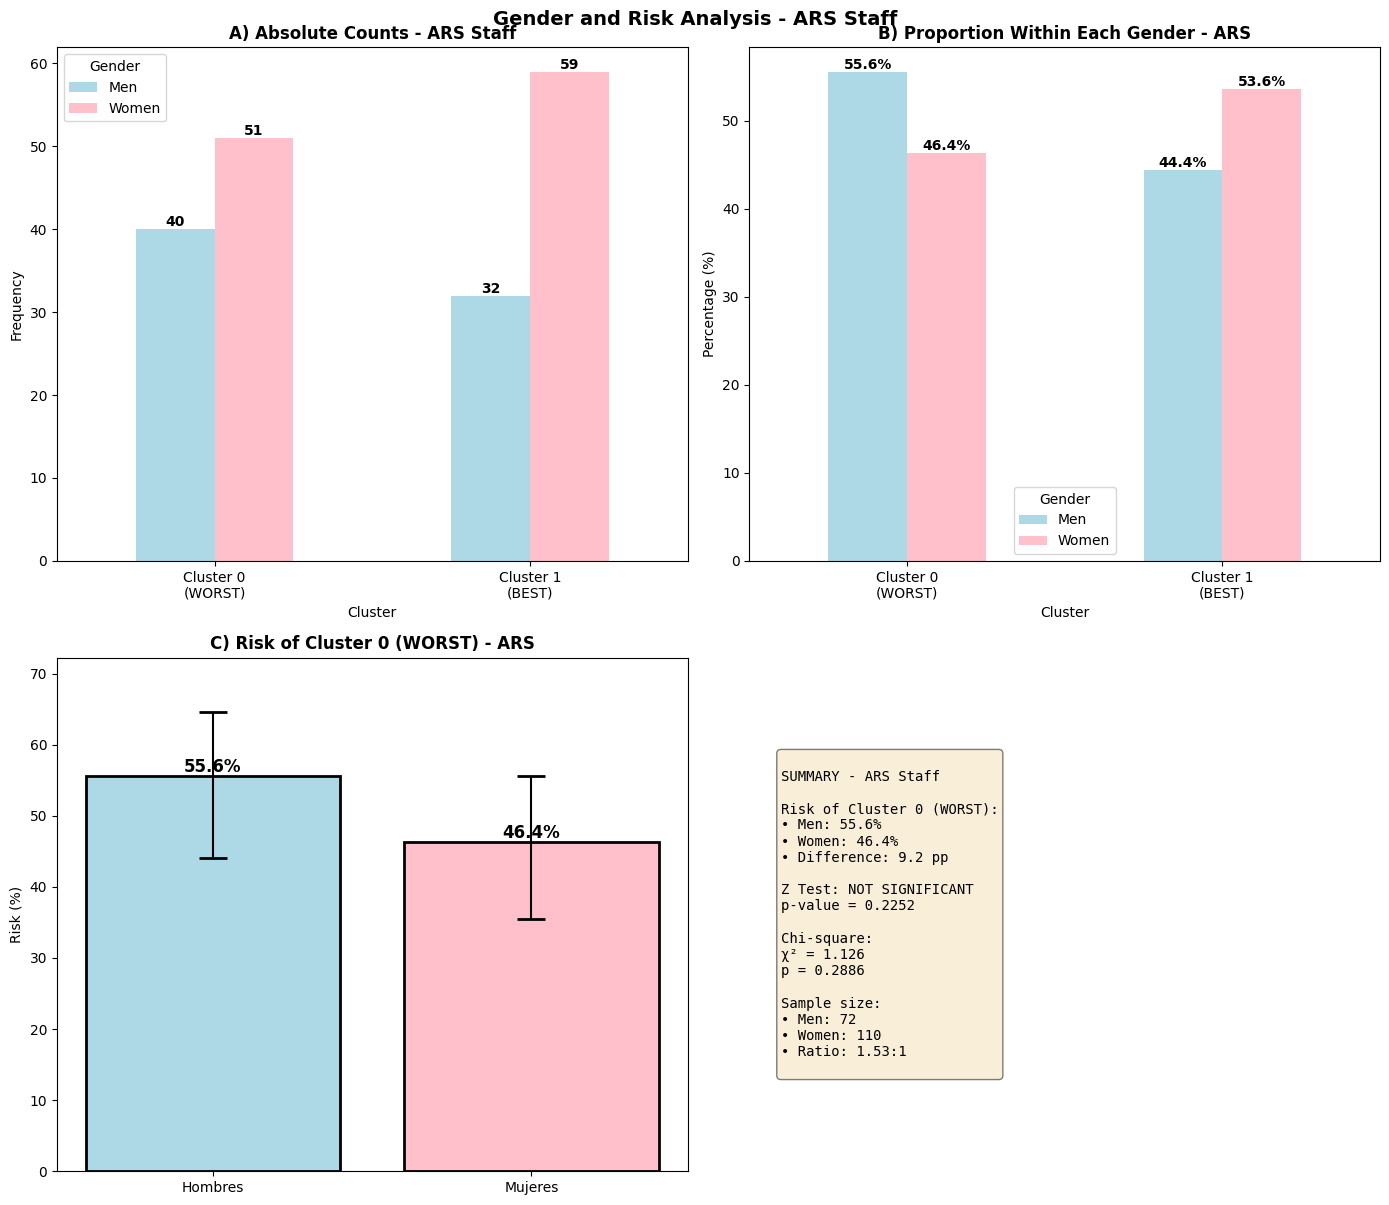


 7. CONCLUSION FOR ARS STAFF

❌ In ARS Staff:
   • Gender is NOT a significant predictor (p = 0.2252)
   • No risk differences between genders

💡 COMPARISON WITH OTHER GROUPS:
   → Compare this result with Students and PAS
   → Identify whether the gender effect is consistent or group-specific



In [36]:
# ============================================================
# JUSTIFICATION: GENDER AND RISK ANALYSIS - PDI STAFF
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print(" INFERENTIAL ANALYSIS: GENDER DIFFERENCES IN RISK - PDI STAFF")
print(" Objective: Determine whether gender is a significant predictor of well-being")
print("="*80)

# ============================================================
# 0. GENDER CODING VERIFICATION
# ============================================================

print("\n" + "="*80)
print(" 0. GENDER CODING VERIFICATION")
print("="*80)

print("\nUnique values of 'genere' in ARS:")
print(ARS['genere'].value_counts().sort_index())

# IMPORTANT: Confirm coding
# If 1=man, 2=woman → Needs recoding as in students
# If already recoded (0=man, 1=woman) → OK

# VERIFY AND RECODE IF NECESSARY
if ARS['genere'].min() == 1:
    print("\n⚠️ ORIGINAL CODING DETECTED: 1=man, 2=woman")
    print("   Recoding to: 0=man, 1=woman (for consistency with students)")
    ARS['genere'] = ARS['genere'].replace({1: 0, 2: 1})
    print("\n✅ Recoding completed:")
    print(ARS['genere'].value_counts().sort_index())
else:
    print("\n✅ Coding already correct: 0=man, 1=woman")

# ============================================================
# 1. DESCRIPTIVE ANALYSIS
# ============================================================

print("\n" + "="*80)
print(" 1. GENDER × CLUSTER DISTRIBUTION")
print("="*80)

# Contingency table
tabla_conteos = pd.crosstab(
    ARS['genere'],
    ARS['Cluster_PDI'],
    margins=True
)

# UPDATED LABELS
genero_labels = {0.0: 'Men', 1.0: 'Women'}
cluster_labels = {0.0: 'Cluster 0 (WORST)', 1.0: 'Cluster 1 (BEST)'}

print("\nA) ABSOLUTE COUNTS:")
tabla_conteos_etiquetada = tabla_conteos.copy()
tabla_conteos_etiquetada.index = [genero_labels.get(idx, idx) for idx in tabla_conteos.index]
print(tabla_conteos_etiquetada)

# Identify key values
n_hombres_total = tabla_conteos.loc[0.0, 'All']
n_mujeres_total = tabla_conteos.loc[1.0, 'All']
n_hombres_cluster0 = tabla_conteos.loc[0.0, 0.0]  # ← CLUSTER 0 = WORST
n_mujeres_cluster0 = tabla_conteos.loc[1.0, 0.0]  # ← CLUSTER 0 = WORST
n_hombres_cluster1 = tabla_conteos.loc[0.0, 1.0]
n_mujeres_cluster1 = tabla_conteos.loc[1.0, 1.0]

# Row percentages (within each gender)
tabla_prop_fila = pd.crosstab(
    ARS['genere'],
    ARS['Cluster_PDI'],
    normalize='index'
) * 100

print(f"\nB) PROPORTIONS WITHIN EACH GENDER (%):")
tabla_prop_etiquetada = tabla_prop_fila.copy()
tabla_prop_etiquetada.index = [genero_labels.get(idx, idx) for idx in tabla_prop_fila.index]
tabla_prop_etiquetada.columns = [cluster_labels[col] for col in tabla_prop_fila.columns]
print(tabla_prop_etiquetada.round(2))

prop_hombres_cluster0 = tabla_prop_fila.loc[0.0, 0.0] / 100  # ← CLUSTER 0
prop_mujeres_cluster0 = tabla_prop_fila.loc[1.0, 0.0] / 100  # ← CLUSTER 0

print(f"\n🎯 RISK COMPARISON (Cluster 0 = WORST well-being):")
print(f"   • Risk in men: {prop_hombres_cluster0:.3f} ({prop_hombres_cluster0*100:.1f}%)")
print(f"   • Risk in women: {prop_mujeres_cluster0:.3f} ({prop_mujeres_cluster0*100:.1f}%)")
print(f"   • Difference: {(prop_hombres_cluster0 - prop_mujeres_cluster0):.3f} ({(prop_hombres_cluster0 - prop_mujeres_cluster0)*100:.1f} pp)")

# ============================================================
# 2. DIFFERENCE IN PROPORTIONS TEST
# ============================================================

print("\n" + "="*80)
print(" 2. STATISTICAL TEST: DIFFERENCE IN PROPORTIONS")
print("="*80)

# Two-proportion Z test (UPDATED FOR CLUSTER 0)
count = np.array([n_hombres_cluster0, n_mujeres_cluster0])  # ← CLUSTER 0
nobs = np.array([n_hombres_total, n_mujeres_total])

z_stat, p_valor = proportions_ztest(count, nobs, alternative='two-sided')

print(f"\nHYPOTHESES:")
print(f"   H0: prop_men = prop_women in Cluster 0 (no real difference)")
print(f"   H1: prop_men ≠ prop_women in Cluster 0 (there is a real difference)")

print(f"\nZ TEST RESULTS:")
print(f"   Z-statistic: {z_stat:.4f}")
print(f"   p-value: {p_valor:.4f}")

if p_valor < 0.05:
    print(f"\n✅ CONCLUSION: Proportions are SIGNIFICANTLY DIFFERENT (p < 0.05)")
    print(f"   → The risk difference between genders is REAL")
    if prop_hombres_cluster0 > prop_mujeres_cluster0:
        print(f"   → MEN have higher risk of worse well-being (Cluster 0)")
    else:
        print(f"   → WOMEN have higher risk of worse well-being (Cluster 0)")
else:
    print(f"\n❌ CONCLUSION: No significant difference (p ≥ 0.05)")
    print(f"   → Gender is NOT a significant predictor for PDI Staff")

# ============================================================
# 3. CONFIDENCE INTERVALS
# ============================================================

print("\n" + "="*80)
print(" 3. CONFIDENCE INTERVALS (95%)")
print("="*80)

# CI for men (CLUSTER 0)
ic_hombres = proportion_confint(n_hombres_cluster0, n_hombres_total, alpha=0.05, method='wilson')

# CI for women (CLUSTER 0)
ic_mujeres = proportion_confint(n_mujeres_cluster0, n_mujeres_total, alpha=0.05, method='wilson')

print(f"\nPROPORTION IN CLUSTER 0 (WORST well-being):")
print(f"\nMen:")
print(f"   Observed proportion: {prop_hombres_cluster0:.3f} ({prop_hombres_cluster0*100:.1f}%)")
print(f"   IC 95%: [{ic_hombres[0]:.3f}, {ic_hombres[1]:.3f}]")
print(f"   IC 95%: [{ic_hombres[0]*100:.1f}%, {ic_hombres[1]*100:.1f}%]")

print(f"\nWomen:")
print(f"   Observed proportion: {prop_mujeres_cluster0:.3f} ({prop_mujeres_cluster0*100:.1f}%)")
print(f"   IC 95%: [{ic_mujeres[0]:.3f}, {ic_mujeres[1]:.3f}]")
print(f"   IC 95%: [{ic_mujeres[0]*100:.1f}%, {ic_mujeres[1]*100:.1f}%]")

# Check if CIs overlap
solapan = not (ic_hombres[1] < ic_mujeres[0] or ic_mujeres[1] < ic_hombres[0])

print(f"\n📊 CI INTERPRETATION:")
if not solapan:
    print(f"   ✅ The intervals DO NOT overlap")
    print(f"   → VERY STRONG evidence of real difference between genders")
else:
    print(f"   ⚠️ The intervals DO overlap")
    print(f"   → The difference is not statistically conclusive")

# ============================================================
# 4. RIESGO RELATIVO Y ODDS RATIO
# ============================================================

print("\n" + "="*80)
print(" 4. MEASURES OF ASSOCIATION")
print("="*80)

# Relative Risk (RR) - UPDATED FOR CLUSTER 0
if prop_mujeres_cluster0 > 0:
    riesgo_relativo = prop_hombres_cluster0 / prop_mujeres_cluster0
else:
    riesgo_relativo = np.inf

# Odds Ratio (OR) - UPDATED FOR CLUSTER 0
if n_mujeres_cluster1 > 0 and n_mujeres_cluster0 > 0:
    odds_hombres = n_hombres_cluster0 / n_hombres_cluster1
    odds_mujeres = n_mujeres_cluster0 / n_mujeres_cluster1
    odds_ratio = odds_hombres / odds_mujeres
    
    # CI for Odds Ratio
    se_log_or = np.sqrt(1/n_hombres_cluster0 + 1/n_hombres_cluster1 + 
                         1/n_mujeres_cluster0 + 1/n_mujeres_cluster1)
    ic_or_inferior = np.exp(np.log(odds_ratio) - 1.96 * se_log_or)
    ic_or_superior = np.exp(np.log(odds_ratio) + 1.96 * se_log_or)
    
    print(f"\nA) RELATIVE RISK (RR):")
    print(f"   RR = {riesgo_relativo:.2f}")
    print(f"   Interpretation: Men have {riesgo_relativo:.2f} times")
    print(f"                   the risk of women of being in Cluster 0 (worse well-being)")
    
    print(f"\nB) ODDS RATIO (OR):")
    print(f"   OR = {odds_ratio:.2f}")
    print(f"   IC 95%: [{ic_or_inferior:.2f}, {ic_or_superior:.2f}]")
    
    if ic_or_inferior > 1.0:
        print(f"\n✅ CONCLUSION: The CI does not include 1.0")
        print(f"   → MEN have higher risk of worse well-being")
    elif ic_or_superior < 1.0:
        print(f"\n✅ CONCLUSION: The CI does not include 1.0")
        print(f"   → WOMEN have higher risk of worse well-being")
    else:
        print(f"\n⚠️ WARNING: The CI includes 1.0")
        print(f"   → The association is not conclusive")
else:
    print(f"\n⚠️ OR cannot be calculated due to cells with value 0")

# ============================================================
# 5. TEST CHI-CUADRADO
# ============================================================

print("\n" + "="*80)
print(" 5. CHI-SQUARE TEST OF INDEPENDENCE")
print("="*80)

chi2, p_chi, dof, expected = chi2_contingency(
    pd.crosstab(ARS['genere'], ARS['Cluster_PDI'])
)

print(f"\nRESULTS:")
print(f"   χ² = {chi2:.4f}")
print(f"   p-valor = {p_chi:.4f}")

# Cramer's V
n = tabla_conteos.loc['All', 'All']
v_cramer = np.sqrt(chi2 / (n * (min(2, 2) - 1)))

print(f"   V de Cramér = {v_cramer:.4f}")

if p_chi < 0.05:
    print(f"\n✅ CONCLUSION: Gender and cluster are ASSOCIATED (p < 0.05)")
else:
    print(f"\n❌ CONCLUSION: No evidence of association (p ≥ 0.05)")

# ============================================================
# 6. VISUALIZACIÓN ACTUALIZADA
# ============================================================

print("\n" + "="*80)
print(" 6. VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Gráfico 1: Conteos absolutos
ax1 = axes[0, 0]
tabla_obs = pd.crosstab(ARS['genere'], ARS['Cluster_PDI'])
tabla_obs.T.plot(kind='bar', ax=ax1, color=['lightblue', 'pink'])
ax1.set_title('A) Absolute Counts - ARS Staff', fontweight='bold')
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Frequency')
ax1.legend(['Men', 'Women'], title='Gender')
ax1.set_xticklabels(['Cluster 0\n(WORST)', 'Cluster 1\n(BEST)'], rotation=0)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontweight='bold')

# Gráfico 2: Proporciones
ax2 = axes[0, 1]
tabla_prop_fila.T.plot(kind='bar', ax=ax2, color=['lightblue', 'pink'])
ax2.set_title('B) Proportion Within Each Gender - ARS', fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Percentage (%)')
ax2.legend(['Men', 'Women'], title='Gender')
ax2.set_xticklabels(['Cluster 0\n(WORST)', 'Cluster 1\n(BEST)'], rotation=0)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', fontweight='bold')

# Gráfico 3: Riesgo de Cluster 0
ax3 = axes[1, 0]
generos = ['Hombres', 'Mujeres']
riesgos = [prop_hombres_cluster0 * 100, prop_mujeres_cluster0 * 100]
bars = ax3.bar(generos, riesgos, color=['lightblue', 'pink'], edgecolor='black', linewidth=2)
ax3.set_title('C) Risk of Cluster 0 (WORST) - ARS', fontweight='bold')
ax3.set_ylabel('Risk (%)')
ax3.set_ylim(0, max(max(riesgos) * 1.3, 10))

# Error bars
yerr_hombres = [(prop_hombres_cluster0 - ic_hombres[0])*100, 
                (ic_hombres[1] - prop_hombres_cluster0)*100]
yerr_mujeres = [(prop_mujeres_cluster0 - ic_mujeres[0])*100, 
                (ic_mujeres[1] - prop_mujeres_cluster0)*100]
ax3.errorbar([0, 1], riesgos, yerr=[yerr_hombres, yerr_mujeres], 
             fmt='none', ecolor='black', capsize=10, capthick=2)

for bar, riesgo in zip(bars, riesgos):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{riesgo:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

# Gráfico 4: Resumen
ax4 = axes[1, 1]
ax4.axis('off')

if p_valor < 0.05:
    conclusion_sig = "SIGNIFICANT"
else:
    conclusion_sig = "NOT SIGNIFICANT"

resumen_texto = f"""
SUMMARY - ARS Staff

Risk of Cluster 0 (WORST):
• Men: {prop_hombres_cluster0*100:.1f}%
• Women: {prop_mujeres_cluster0*100:.1f}%
• Difference: {(prop_hombres_cluster0-prop_mujeres_cluster0)*100:.1f} pp

Z Test: {conclusion_sig}
p-value = {p_valor:.4f}

Chi-square:
χ² = {chi2:.3f}
p = {p_chi:.4f}

Sample size:
• Men: {n_hombres_total}
• Women: {n_mujeres_total}
• Ratio: {n_mujeres_total/n_hombres_total:.2f}:1
"""

ax4.text(0.05, 0.5, resumen_texto, fontsize=10, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', 
         facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.suptitle('Gender and Risk Analysis - ARS Staff', 
             fontsize=14, fontweight='bold', y=1.00)
plt.show()

# ============================================================
# 7. FINAL CONCLUSION
# ============================================================

print("\n" + "="*80)
print(" 7. CONCLUSION FOR ARS STAFF")
print("="*80)

if p_valor < 0.05:
    if prop_hombres_cluster0 > prop_mujeres_cluster0:
        grupo_riesgo = "MEN"
    else:
        grupo_riesgo = "WOMEN"
    
    print(f"\n✅ In ARS Staff:")
    print(f"   • Gender IS a significant predictor (p = {p_valor:.4f})")
    print(f"   • {grupo_riesgo} have higher risk of worse well-being")
    print(f"   • Difference: {abs(prop_hombres_cluster0-prop_mujeres_cluster0)*100:.1f} pp")
    if 'riesgo_relativo' in locals():
        print(f"   • Relative Risk: {riesgo_relativo:.2f}")
else:
    print(f"\n❌ In ARS Staff:")
    print(f"   • Gender is NOT a significant predictor (p = {p_valor:.4f})")
    print(f"   • No risk differences between genders")

print("\n💡 COMPARISON WITH OTHER GROUPS:")
print("   → Compare this result with Students and PAS")
print("   → Identify whether the gender effect is consistent or group-specific")

print("\n" + "="*80)

In [ ]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import numpy as np

# Reemplaza estos valores por los reales de tu tabla:
n_hombres_cluster0 = 40  # número de hombres en cluster 0
n_mujeres_cluster0 = 51  # número de mujeres en cluster 0
n_hombres_total = 72     # total hombres
n_mujeres_total = 110     # total mujeres

count = np.array([n_hombres_cluster0, n_mujeres_cluster0])
nobs = np.array([n_hombres_total, n_mujeres_total])

z_stat, p_valor = proportions_ztest(count, nobs, alternative='two-sided')
ic_low, ic_upp = confint_proportions_2indep(count1=n_hombres_cluster0, nobs1=n_hombres_total,
                                            count2=n_mujeres_cluster0, nobs2=n_mujeres_total,
                                            method='wald')

diferencia = (n_mujeres_cluster0 / n_mujeres_total) - (n_hombres_cluster0 / n_hombres_total)

print(f"Diferencia de proporciones: {diferencia*100:.1f} pp")
print(f"IC 95% para la diferencia: [{ic_low*100:.1f}, {ic_upp*100:.1f}] pp")
print(f"Z = {z_stat:.2f}, p = {p_valor:.3f}")



Diferencia de proporciones: -9.2 pp
IC 95% para la diferencia: [-5.6, 24.0] pp
Z = 1.21, p = 0.225
